肺部和结肠组织病理分类任务
本Notebook基于LC25000数据集，实现肺部和结肠组织病理图像的分类。
数据集：data/cancer（假设已解压cancer.zip）。
类别：colon_aca, colon_n, lung_aca, lung_n, lung_scc。
核心技术：数据集处理、迁移学习、模型评估、Grad-CAM。
权重文件：使用pretrained_models文件夹中的本地权重。

In [2]:
# 准备工作：安装库（如果未安装）
!pip install seaborn torchcam

# 加载相关库
import os
from IPython.display import display, Markdown
from PIL import Image
from tqdm import tqdm
from collections import Counter
from collections import defaultdict
from matplotlib import pyplot as plt
import cv2
import numpy as np
import time
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models import resnet18, densenet121, resnet50, vgg16
import torch.optim as optim
from torchcam.methods import GradCAM as TorchCAMGradCAM
from torchcam.utils import overlay_mask

# 如果在华为云或需要解压（本地可手动解压）
# !unzip cancer.zip

查看数据集文件夹结构

In [3]:
# 指定要检查的文件夹路径
folder_path = 'cancer'  # 替换为你的文件夹路径

# 定义常见的图片格式后缀
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}

# 非递归：只列出顶层内容
print("Top-level contents of", folder_path)
for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isdir(item_path):
        print(f"Dir: {item}")
    else:
        print(f"File: {item}")

# 递归：列出所有层级结构，限制图片数量
print("\nFull directory structure of", folder_path)
def print_directory_structure(path, prefix=""):
    items = os.listdir(path)
    files = [item for item in items if os.path.isfile(os.path.join(path, item))]

    # 检查是否多为图片文件
    image_count = sum(1 for f in files if os.path.splitext(f)[1].lower() in image_extensions)
    total_files = len(files)
    is_mostly_images = total_files > 0 and (image_count / total_files) > 0.5

    for item in items:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"{prefix}Dir: {item}")
            print_directory_structure(item_path, prefix + "  ")
        else:
            if is_mostly_images:
                image_files = [f for f in files if os.path.splitext(f)[1].lower() in image_extensions]
                if item in image_files:
                    idx = image_files.index(item)
                    if idx < 3:
                        print(f"{prefix}File: {item}")
                    elif idx == 3:
                        print(f"{prefix}File: ...")
            else:
                print(f"{prefix}File: {item}")

print_directory_structure(folder_path)

Top-level contents of cancer
Dir: colon_aca
Dir: colon_n
Dir: lung_aca
Dir: lung_n
Dir: lung_scc

Full directory structure of cancer
Dir: colon_aca
  File: colon_aca0001.jpeg
  File: colon_aca0002.jpeg
  File: colon_aca0003.jpeg
  File: ...
Dir: colon_n
  File: colonn0001.jpeg
  File: colonn0002.jpeg
  File: colonn0003.jpeg
  File: ...
Dir: lung_aca
  File: lungaca0001.jpeg
  File: lungaca0002.jpeg
  File: lungaca0003.jpeg
  File: ...
Dir: lung_n
  File: lungn0001.jpeg
  File: lungn0002.jpeg
  File: lungn0003.jpeg
  File: ...
Dir: lung_scc
  File: lungscc0001.jpeg
  File: lungscc0002.jpeg
  File: lungscc0003.jpeg
  File: ...


数据预备：计算Laplacian方差并统计

In [4]:
def calculate_laplacian_variance(img_path):
    """计算图像的Laplacian方差"""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"警告: 无法加载图像 {img_path}")
        return None
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

# 数据集目录
dataset_dir = 'cancer'

# 用于存储结果：{标签: [方差列表]}
results = defaultdict(list)

for root, dirs, files in os.walk(dataset_dir):
    label = os.path.basename(root) if root != dataset_dir else "unknown"

    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            laplacian_var = calculate_laplacian_variance(img_path)
            if laplacian_var is not None:
                results[label].append(laplacian_var)

# 统计和输出结果
for label, variances in results.items():
    variances = np.array(variances)
    print(f"\n标签: {label}")
    print(f"  样本数: {len(variances)}")
    print(f"  平均方差: {np.mean(variances):.2f}")
    print(f"  标准差: {np.std(variances):.2f}")
    print(f"  最小值: {np.min(variances):.2f}")
    print(f"  最大值: {np.max(variances):.2f}")


标签: colon_aca
  样本数: 1000
  平均方差: 117.48
  标准差: 78.00
  最小值: 15.05
  最大值: 475.66

标签: colon_n
  样本数: 1000
  平均方差: 98.66
  标准差: 56.73
  最小值: 13.03
  最大值: 288.00

标签: lung_aca
  样本数: 1000
  平均方差: 19.32
  标准差: 8.01
  最小值: 6.32
  最大值: 48.56

标签: lung_n
  样本数: 1000
  平均方差: 16.41
  标准差: 6.47
  最小值: 4.61
  最大值: 38.40

标签: lung_scc
  样本数: 1000
  平均方差: 21.71
  标准差: 10.29
  最小值: 5.59
  最大值: 83.61


绘制Laplacian方差分布

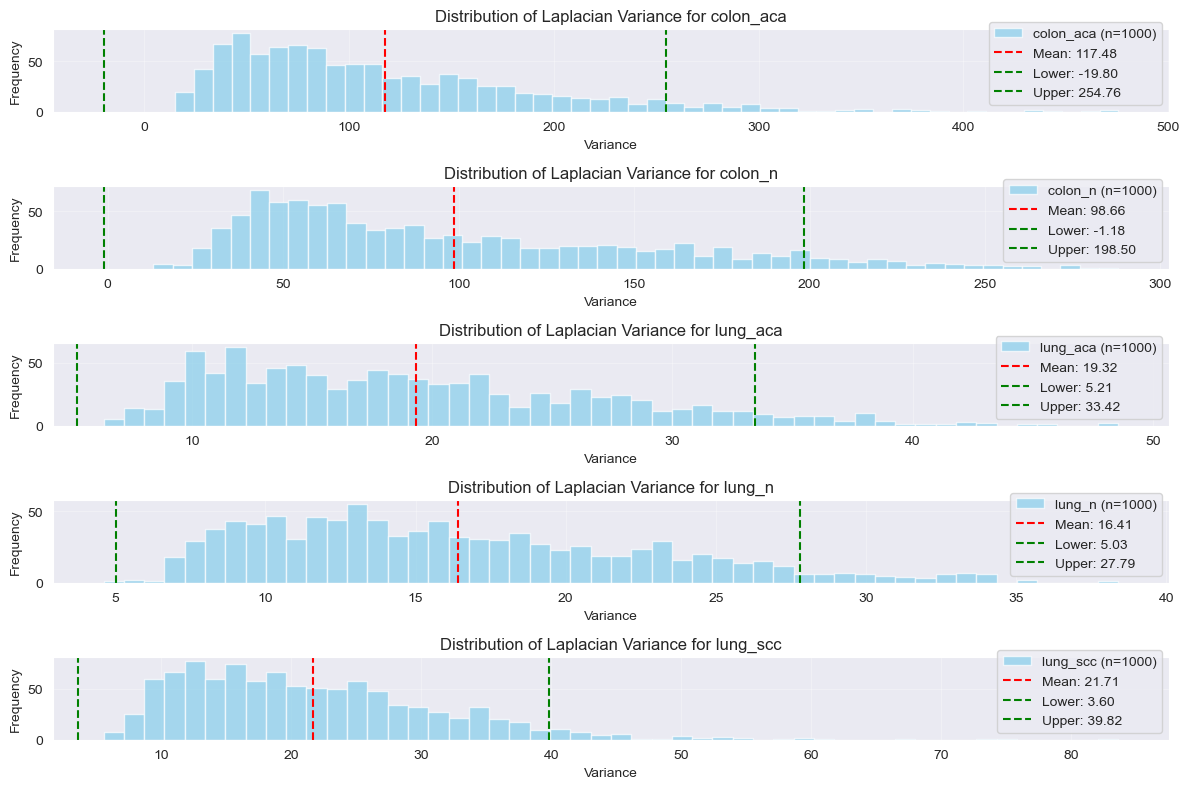

In [5]:
# 统计、绘图和阈值计算
lower_threshold_list = []
plt.figure(figsize=(12, 8))
for i, (label, variances) in enumerate(results.items(), 1):
    variances = np.array(variances)

    mean_var = np.mean(variances)
    std_var = np.std(variances)
    min_var = np.min(variances)
    max_var = np.max(variances)

    limit = 1.76
    lower_threshold = mean_var - limit * std_var
    upper_threshold = mean_var + limit * std_var

    lower_threshold_list.append(lower_threshold)

    plt.subplot(len(results), 1, i)
    plt.hist(variances, bins=50, color='skyblue', alpha=0.7, label=f'{label} (n={len(variances)})')
    plt.axvline(mean_var, color='red', linestyle='--', label=f'Mean: {mean_var:.2f}')
    plt.axvline(lower_threshold, color='green', linestyle='--', label=f'Lower: {lower_threshold:.2f}')
    plt.axvline(upper_threshold, color='green', linestyle='--', label=f'Upper: {upper_threshold:.2f}')
    plt.title(f"Distribution of Laplacian Variance for {label}")
    plt.xlabel("Variance")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('laplacian_variance.svg', format='svg')
plt.show()

核心：数据集读取 - CustomDataset类

In [6]:
class CustomDataset(Dataset):
    def __init__(self, dataset_dir, target_size=(224, 224), transform=None):
        self.dataset_dir = dataset_dir
        self.target_size = target_size
        self.transform = transform
        self.images = []
        self.labels = []
        # 仅包含子目录作为类别
        self.classes = sorted([c for c in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, c))])

        for label, folder in enumerate(self.classes):
            folder_path = os.path.join(dataset_dir, folder)
            if os.path.isdir(folder_path):
                for filename in os.listdir(folder_path):
                    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                        img_path = os.path.join(folder_path, filename)
                        self.images.append(img_path)
                        self.labels.append(label)

        if self.transform is None:
            self.transform = transforms.Compose([
                transforms.Resize(self.target_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

预设变换并创建全局数据集

In [7]:
# 数据增强和变换
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建完整数据集实例
dataset_dir = 'cancer'
full_dataset = CustomDataset(dataset_dir, transform=None)  # 先不应用变换

# 查看标签对应
for label, folder in enumerate(full_dataset.classes):
    print(label, folder)

0 colon_aca
1 colon_n
2 lung_aca
3 lung_n
4 lung_scc


绘制5类图像案例

In [8]:
import os
print(f"当前工作目录: {os.getcwd()}")
print(f"cancer 内容: {os.listdir('cancer')}")

当前工作目录: D:\pycharm community\machine learning test\肺部和结肠组织病理分类任务
cancer 内容: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [9]:
print(f"full_dataset.classes: {full_dataset.classes}")
print(f"full_dataset.classes 长度: {len(full_dataset.classes)}")
print(f"full_dataset 总图像数: {len(full_dataset)}")
class_counts = {}
for label in range(len(full_dataset.classes)):
    class_counts[label] = sum(1 for _, lbl in full_dataset if lbl == label)
print(f"每个类别的图像数量: {class_counts}")

full_dataset.classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
full_dataset.classes 长度: 5
full_dataset 总图像数: 5000
每个类别的图像数量: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}


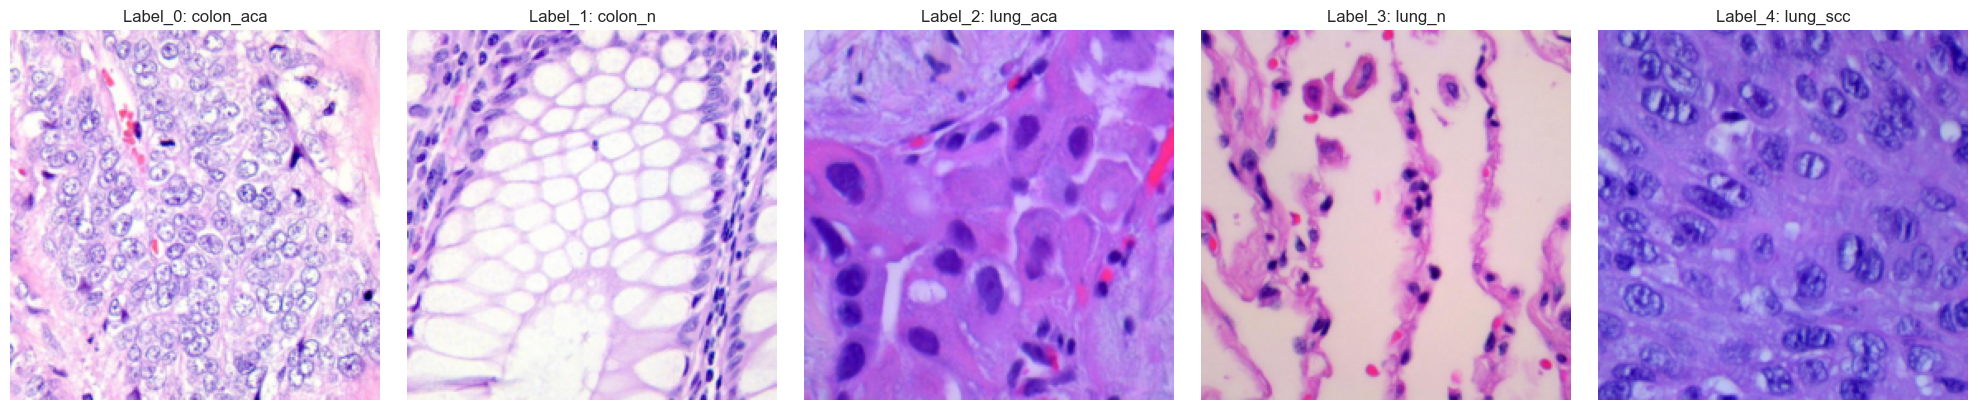

In [10]:
# 收集标签0到4的样本图像
label_to_image = {}
for image, label in full_dataset:
    lbl = label
    if lbl not in label_to_image and lbl < 5:
        label_to_image[lbl] = image
    if len(label_to_image) == 5:
        break

# 创建一行五列的子图
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx in range(5):
    if idx in label_to_image:
        image = label_to_image[idx]
        image_np = image.permute(1, 2, 0).numpy()
        image_denorm = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        image_denorm = np.clip(image_denorm, 0, 1)

        axes[idx].imshow(image_denorm)
        class_name = full_dataset.classes[idx]
        axes[idx].set_title(f"Label_{idx}: {class_name}")
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, "No sample", ha='center', va='center')
        axes[idx].set_title(f"Label_{idx}: {full_dataset.classes[idx]}")
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig('class_examples.svg', format='svg')
plt.show()

训练集、验证集、测试集建立

In [11]:
# 数据集分割
dataset_size = len(full_dataset)
indices = torch.randperm(dataset_size).tolist()

train_ratio, val_ratio = 0.7, 0.15
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)
test_size = dataset_size - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# 创建子集
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

# 应用变换
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 查看训练样本情况（示例一批次）
for images, labels in train_loader:
    print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")
    break

Images shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


基于迁移学习建立模型（ResNet18）

In [12]:
# 加载预训练的 ResNet18 模型
from torchvision.models import resnet18
model = resnet18(pretrained=True)  # 加载预训练的 ResNet18 模型，参数从 ImageNet 初始化

# 修改分类器以适配你的数据集类别数
num_classes = len(full_dataset.classes)  # 获取数据集的类别总数（应为 5）
model.fc = nn.Linear(model.fc.in_features, num_classes)  # 替换全连接层，输入特征数不变，输出为类别数

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # 检查是否有 GPU，否则使用 CPU
model = model.to(device)  # 将模型移动到指定设备（GPU 或 CPU）

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 使用交叉熵损失函数，适用于多分类任务
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # 使用 SGD 优化器，学习率 0.001，动量 0.9

# 假设已运行你的数据集分割代码，确保 train_loader, val_loader, test_loader 已定义
print(f"训练集大小: {len(train_dataset)}, 验证集大小: {len(val_dataset)}, 测试集大小: {len(test_dataset)}")

训练集大小: 3500, 验证集大小: 750, 测试集大小: 750


D:\anaconda\envs\machine learning test\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\anaconda\envs\machine learning test\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


训练和评估函数

Training:  10%|█         | 1/10 [02:23<21:33, 143.75s/it]

Epoch [1/10], Train Loss: 0.3838, Val Loss: 0.1268


Training:  20%|██        | 2/10 [06:10<25:40, 192.58s/it]

Epoch [2/10], Train Loss: 0.0945, Val Loss: 0.0751


Training:  30%|███       | 3/10 [10:10<24:58, 214.05s/it]

...

Epoch [8/10], Train Loss: 0.0118, Val Loss: 0.0434


Training:  90%|█████████ | 9/10 [23:05<02:00, 120.95s/it]

Epoch [9/10], Train Loss: 0.0131, Val Loss: 0.0523


Training: 100%|██████████| 10/10 [24:43<00:00, 148.34s/it]

Epoch [10/10], Train Loss: 0.0116, Val Loss: 0.0407

验证集评估指标:
准确率 (Accuracy): 0.9907
精确率 (Precision, macro): 0.9909
召回率 (Recall, macro): 0.9909
F1 分数 (F1 Score, macro): 0.9909


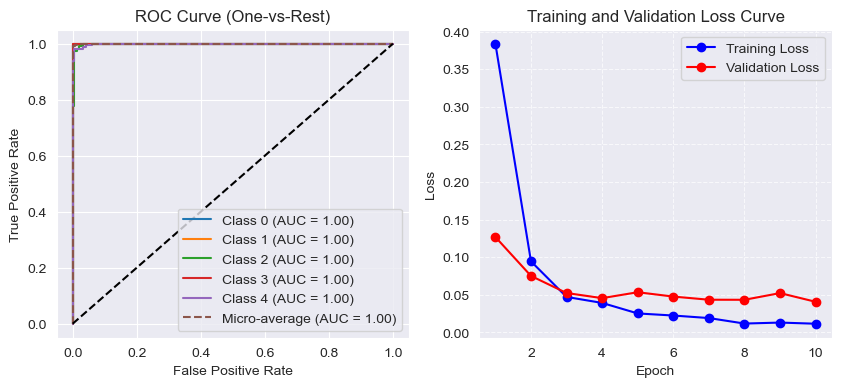

In [13]:
# 训练和评估函数
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize  # 修正导入位置

def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, num_epochs, num_classes=5):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in tqdm(range(num_epochs), desc="Training"):
        # 训练阶段
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # 验证阶段
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        all_probs = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

    model.load_state_dict(best_model_state)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

    print("\n验证集评估指标:")
    print(f"准确率 (Accuracy): {accuracy:.4f}")
    print(f"精确率 (Precision, macro): {precision:.4f}")
    print(f"召回率 (Recall, macro): {recall:.4f}")
    print(f"F1 分数 (F1 Score, macro): {f1:.4f}")

    all_labels_bin = label_binarize(all_labels, classes=range(num_classes))
    fpr, tpr, roc_auc = {}, {}, {}

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})', linestyle='--')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='best')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o', color='b')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o', color='r')
    plt.title('Training and Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.savefig('resnet18_training.svg', format='svg')
    plt.show()

    return train_losses, val_losses, accuracy, precision, recall, f1, roc_auc

# 示例运行
num_epochs = 10
train_losses, val_losses, accuracy, precision, recall, f1, roc_auc = train_and_evaluate(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, num_classes=5
)

模型保存、加载与测试

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

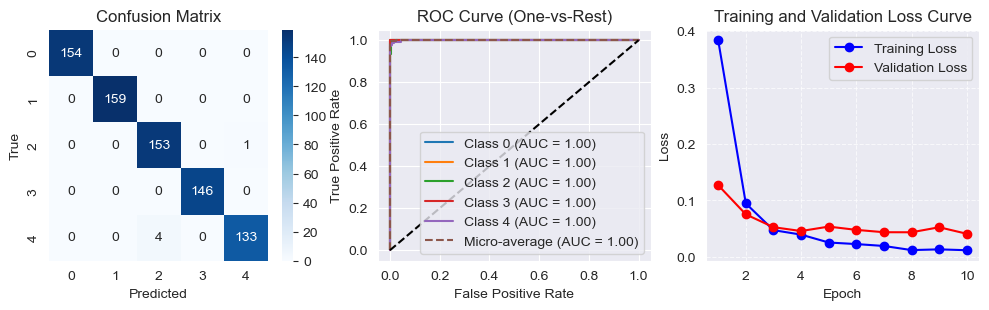

In [14]:
# 保存模型
torch.save(model.state_dict(), 'resnet_model.pth')

# 加载模型
model.load_state_dict(torch.load('resnet_model.pth', map_location=device))
model.eval()

# 查看模型结构
print(model)

# 模型测试
model.eval()
correct = 0
total = 0
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

accuracy = 100 * correct / total
print(f"测试集准确率 (Accuracy): {accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
print(f"精确率 (Precision, macro): {precision:.4f}")
print(f"召回率 (Recall, macro): {recall:.4f}")
print(f"F1 分数 (F1 Score, macro): {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 3))
plt.subplot(1,3,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

all_labels_bin = label_binarize(all_labels, classes=range(num_classes))
fpr, tpr, roc_auc = {}, {}, {}

plt.subplot(1,3,2)
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], np.array(all_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), np.array(all_probs).ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='best')
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o', color='b')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o', color='r')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.savefig('test_performance.svg', format='svg')
plt.show()

D:\anaconda\envs\machine learning test\lib\site-packages\torch\nn\modules\module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019607849121093757..1.4000000023841856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00784314727783203..1.4000000059604645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00784314727783203..1.3882352566719054].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..2

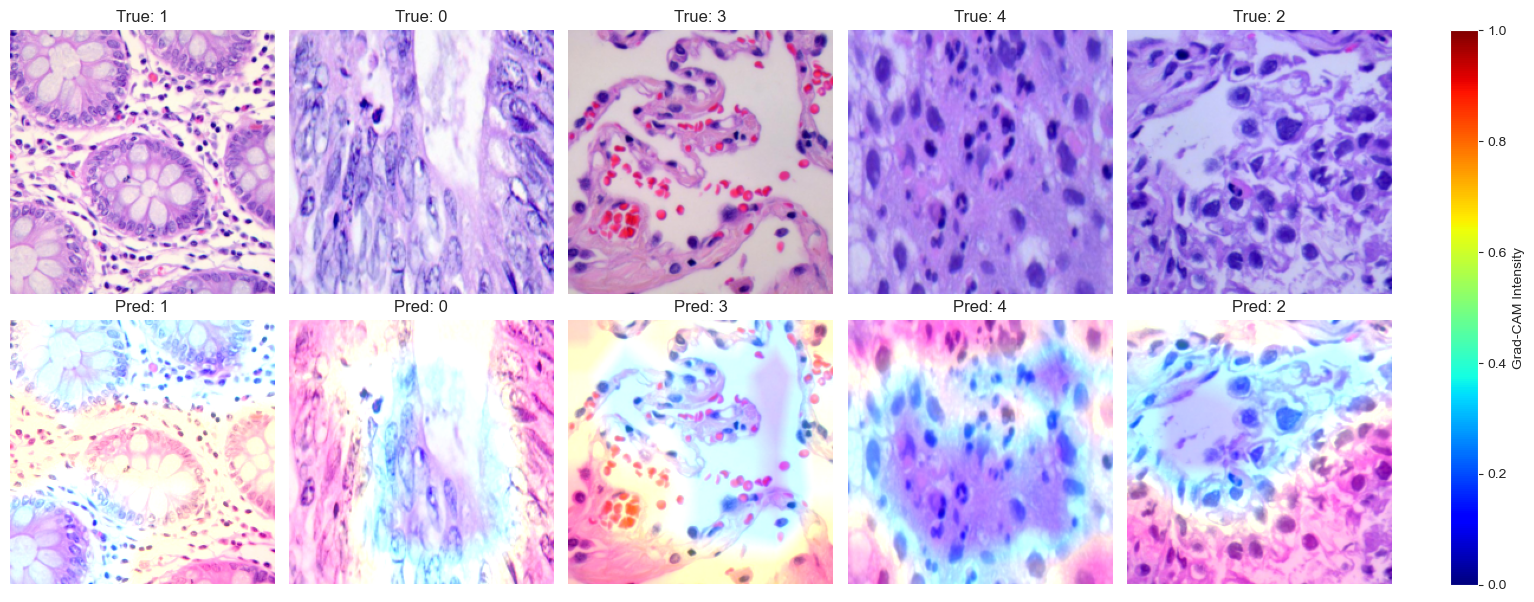

In [16]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Grad-CAM 类（针对 ResNet18）
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()  # 设置为评估模式
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # 注册前向和反向钩子
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output  # 保存激活值

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]  # 保存梯度

    def generate(self, input_image, target_class=None):
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()  # 默认使用最大概率类别

        self.model.zero_grad()
        output[:, target_class].backward()  # 反向传播到目标类别

        gradients = self.gradients
        activations = self.activations
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)  # 全局平均池化梯度

        cam = torch.sum(weights * activations, dim=1).squeeze()  # 加权激活
        cam = F.relu(cam)  # 仅保留正值
        cam = cam.detach().cpu().numpy()

        # 调整热力图大小以匹配输入图像
        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # 归一化到 [0, 1]

        return cam, target_class

# Grad-CAM 可视化函数
def visualize_gradcam(test_loader, model, num_images=5, device=device, num_classes=5):
    model.eval()
    label_to_image = {}  # 存储每个类别的代表图像

    # 收集不同类别的图像
    for images, labels in test_loader:
        for img, lbl in zip(images, labels):
            lbl_item = lbl.item()
            if lbl_item not in label_to_image and len(label_to_image) < num_images:
                label_to_image[lbl_item] = img
            if len(label_to_image) == num_images:
                break
        if len(label_to_image) == num_images:
            break

    # 针对 ResNet18 的目标层（最后一层残差块）
    target_layer = model.layer4[-1]
    grad_cam = GradCAM(model, target_layer)

    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 3, 6))
    all_cams = []

    # 处理每张图像
    for idx, (label, image) in enumerate(label_to_image.items()):
        input_image = image.unsqueeze(0).to(device)
        original_image = image.permute(1, 2, 0).numpy()

        cam, predicted_class = grad_cam.generate(input_image)
        all_cams.append(cam)

        # 生成热力图并叠加
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        # 反归一化图像（假设使用了 ImageNet 归一化）
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        original_image_denorm = original_image * std + mean
        original_image_denorm = np.clip(original_image_denorm, 0, 1)
        superimposed_img = heatmap * 0.4 + original_image_denorm

        # 绘制原始图像
        axes[0, idx].imshow(original_image_denorm)
        axes[0, idx].set_title(f"True: {label}")
        axes[0, idx].axis('off')

        # 绘制叠加热力图
        axes[1, idx].imshow(superimposed_img)
        axes[1, idx].set_title(f"Pred: {predicted_class}")
        axes[1, idx].axis('off')

    # 添加颜色条
    all_cams = np.concatenate(all_cams)
    vmin, vmax = all_cams.min(), all_cams.max()
    cmap = plt.get_cmap('jet')
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.tight_layout()
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Grad-CAM Intensity')

    plt.savefig('gradcam_resnet18.svg', format='svg')
    plt.show()

# 运行 Grad-CAM 可视化
visualize_gradcam(test_loader, model, num_images=5, device=device, num_classes=5)

In [15]:
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")
    break

Batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


模型对比与选优

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Subset
import os
from tqdm import tqdm

# 定义多种模型
model_configs = {
    'densenet121': models.densenet121(pretrained=False),
    'ResNet50': models.resnet50(pretrained=False),
    'VGG16': models.vgg16(pretrained=False),
}
num_classes = len(full_dataset.classes)  # 使用 full_dataset 获取类别数

# 定义预训练权重路径
pretrained_paths = {
    'densenet121': 'pretrained_model/densenet121-a639ec97.pth',
    'ResNet50': 'pretrained_model/resnet50-19c8e357.pth',
    'VGG16': 'pretrained_model/vgg16-397923af.pth',
}

# 调整分类层并加载权重
for name, model in model_configs.items():
    # 先调整分类层
    if 'ResNet' in name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif 'VGG' in name:
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif 'densenet' in name:
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    # 加载预训练权重，仅应用到兼容层
    if os.path.exists(pretrained_paths[name]):
        state_dict = torch.load(pretrained_paths[name], map_location=device, weights_only=False)  # 显式设置 weights_only=False
        # 过滤掉 classifier 层
        model_dict = model.state_dict()
        state_dict = {k: v for k, v in state_dict.items() if k in model_dict and not k.startswith('classifier') and not k.startswith('fc')}
        model_dict.update(state_dict)
        model.load_state_dict(model_dict, strict=False)
        print(f"已加载本地权重（仅卷积层）: {pretrained_paths[name]}")
    else:
        print(f"警告: 未找到权重文件 {pretrained_paths[name]}，将使用随机初始化的权重")

    model = model.to(device)

# 训练函数（简化版，用于多模型）
def train_and_evaluate_multi(model, train_loader, val_loader, criterion, optimizer, num_epochs, name):
    train_losses = []
    val_losses = []
    val_accuracies = []
    start_time = time.time()

    for epoch in tqdm(range(num_epochs), desc=f"Training {name}"):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"{name} - Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    training_time = time.time() - start_time
    return train_losses, val_losses, val_accuracies, training_time

# 训练所有模型
results_dict = {}
criterion = nn.CrossEntropyLoss()
num_epochs = 10  # 假设训练 10 个 epoch

for name, model in model_configs.items():
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses, val_accuracies, training_time = train_and_evaluate_multi(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, name
    )
    results_dict[name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'training_time': training_time
    }

# 添加ResNet18到配置
extra_model = models.resnet18(pretrained=False)
extra_model.fc = nn.Linear(extra_model.fc.in_features, num_classes)
pretrained_path = 'pretrained_model/resnet18-f37072fd.pth'  # 使用你提供的文件名
if os.path.exists(pretrained_path):
    state_dict = torch.load(pretrained_path, map_location=device, weights_only=False)  # 显式设置 weights_only=False
    model_dict = extra_model.state_dict()
    state_dict = {k: v for k, v in state_dict.items() if k in model_dict and not k.startswith('fc')}
    model_dict.update(state_dict)
    extra_model.load_state_dict(model_dict, strict=False)
    print(f"已加载本地权重（仅卷积层）: {pretrained_path}")
else:
    print(f"警告: 未找到权重文件 {pretrained_path}，将使用随机初始化的权重")
extra_model = extra_model.to(device)
model_configs['ResNet18'] = extra_model

评估多模型

In [ ]:
def evaluate_models(model_configs, test_loader, num_classes=5):
    results = {}

    for name, model in model_configs.items():
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

        accuracy = 100 * correct / total
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

        all_labels_bin = label_binarize(all_labels, classes=range(num_classes))
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], np.array(all_probs)[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), np.array(all_probs).ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        cm = confusion_matrix(all_labels, all_preds)

        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

        print(f"\n模型: {name}")
        print(f"准确率 (Accuracy): {accuracy:.2f}%")
        print(f"精确率 (Precision, macro): {precision:.4f}")
        print(f"召回率 (Recall, macro): {recall:.4f}")
        print(f"F1 分数 (F1 Score, macro): {f1:.4f}")
        print(f"Micro-average AUC: {roc_auc['micro']:.4f}")

    return results

# 运行评估
results = evaluate_models(model_configs, test_loader, num_classes=5)

# 可视化ROC
plt.figure(figsize=(12, 8))
for name, result in results.items():
    plt.plot(result['fpr']['micro'], result['tpr']['micro'],
             label=f'{name} (AUC = {result["roc_auc"]["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-average)')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('multi_model_roc.svg', format='svg')
plt.show()

# 指标对比表
print("\n指标对比表:")
print(f"{'Model':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'AUC':<10}")
for name, result in results.items():
    print(f"{name:<15} {result['accuracy']:<10.2f} {result['precision']:<10.4f} {result['recall']:<10.4f} {result['f1']:<10.4f} {result['roc_auc']['micro']:<10.4f}")

# 选优
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = model_configs[best_model_name]
print(f"\n最优模型: {best_model_name}")

Grad-CAM：模型可解释性分析

In [ ]:
# Grad-CAM类（文档版本）
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, target_class=None):
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[:, target_class].backward()

        gradients = self.gradients
        activations = self.activations
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        cam = torch.sum(weights * activations, dim=1).squeeze()
        cam = F.relu(cam)
        cam = cam.detach().cpu().numpy()

        cam = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, target_class

# 可视化函数
def visualize_gradcam(test_loader, best_model, num_images=5, device=device):
    label_to_image = {}
    for images, labels in test_loader:
        for img, lbl in zip(images, labels):
            lbl_item = lbl.item()
            if lbl_item not in label_to_image and len(label_to_image) < num_images:
                label_to_image[lbl_item] = img
            if len(label_to_image) == num_images:
                break
        if len(label_to_image) == num_images:
            break

    target_layer = best_model.layer4[-1] if 'ResNet' in best_model_name else best_model.features[-1] if 'VGG' in best_model_name else best_model.features.denseblock4.denselayer16.conv2
    grad_cam = GradCAM(best_model, target_layer)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    all_cams = []

    for idx, (label, image) in enumerate(label_to_image.items()):
        input_image = image.unsqueeze(0).to(device)
        original_image = image.permute(1, 2, 0).numpy()

        cam, predicted_class = grad_cam.generate(input_image)
        all_cams.append(cam)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        original_image_denorm = original_image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        original_image_denorm = np.clip(original_image_denorm, 0, 1)
        superimposed_img = heatmap * 0.4 + original_image_denorm

        axes[0, idx].imshow(original_image_denorm)
        axes[0, idx].set_title(f"Label: {label}")
        axes[0, idx].axis('off')

        axes[1, idx].imshow(superimposed_img)
        axes[1, idx].set_title(f"Pred: {predicted_class}")
        axes[1, idx].axis('off')

    all_cams = np.concatenate(all_cams)
    vmin, vmax = all_cams.min(), all_cams.max()

    cmap = plt.get_cmap('jet')
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.tight_layout()
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Grad-CAM Intensity')
    plt.savefig('gradcam_visualization.svg', format='svg')
    plt.show()

# 运行Grad-CAM可视化（使用最优模型）
visualize_gradcam(test_loader, best_model)

项目小结
运行完以上单元格，即完成整个流程。结果保存在SVG文件中。